In [13]:
import json
import pandas as pd
from pathlib import Path

OUTDIR = r".\resultados"
SWAP = True  # inversão de especificidade/sensibilidade (depende se positivo significa maligno ou benigno)

# ---- Tabela 5 (linha PSO), em % ----
ART = {
    "Accuracy":     {"Without FS": 96.4, "With FS": 97.2},
    "Specificity":  {"Without FS": 93.1, "With FS": 95.6},
    "Sensitivity":  {"Without FS": 98.6, "With FS": 98.0},
}

# ---- Resultados ----
s = json.loads(Path(OUTDIR, "wdbc_summary.json").read_text(encoding="utf-8"))

base_acc = s["base_accuracy_mean"]
fs_acc   = s["fs_accuracy_mean"]
base_sens = s["base_sensitivity_mean"]
fs_sens   = s["fs_sensitivity_mean"]
base_spec = s["base_specificity_mean"]
fs_spec   = s["fs_specificity_mean"]

if SWAP:
    base_sens, base_spec = base_spec, base_sens
    fs_sens, fs_spec     = fs_spec, fs_sens

MY = {
    "Accuracy":     {"Without FS": base_acc*100, "With FS": fs_acc*100},
    "Specificity":  {"Without FS": base_spec*100, "With FS": fs_spec*100},
    "Sensitivity":  {"Without FS": base_sens*100, "With FS": fs_sens*100},
}

# ---- Comparação (mesmas colunas do artigo + diffs) ----
rows = []
for metric in ["Accuracy", "Specificity", "Sensitivity"]:
    aw = ART[metric]["Without FS"]
    av = ART[metric]["With FS"]
    mw = MY[metric]["Without FS"]
    mv = MY[metric]["With FS"]
    rows.append({
        "Métrica": metric,
        "Artigo sem FS": round(aw, 1),
        "Réplica sem FS": round(mw, 1),
        "Diff sem": round(mw-aw, 1),
        "Artigo com FS": round(av, 1),
        "Réplica com FS": round(mv, 1),
        "Diff com": round(mv-av, 1),
    })

df = pd.DataFrame(rows)
df


,Métrica,Artigo sem FS,Réplica sem FS,Diff sem,Artigo com FS,Réplica com FS,Diff com
0,Accuracy,96.4,96.5,0.1,97.2,96.5,-0.7
1,Specificity,93.1,94.2,1.1,95.6,93.9,-1.7
2,Sensitivity,98.6,97.8,-0.8,98.0,98.1,0.1


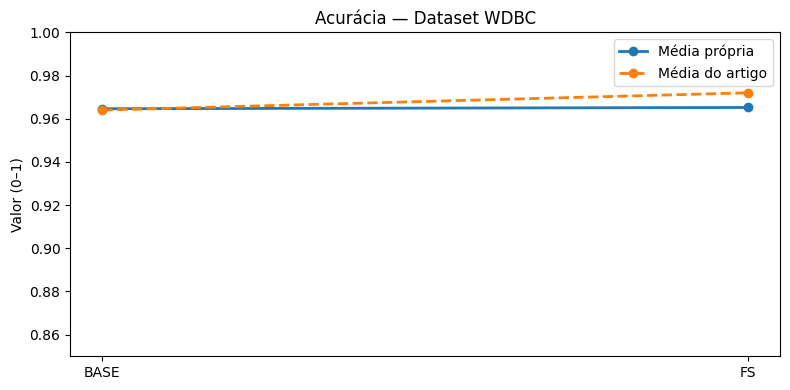

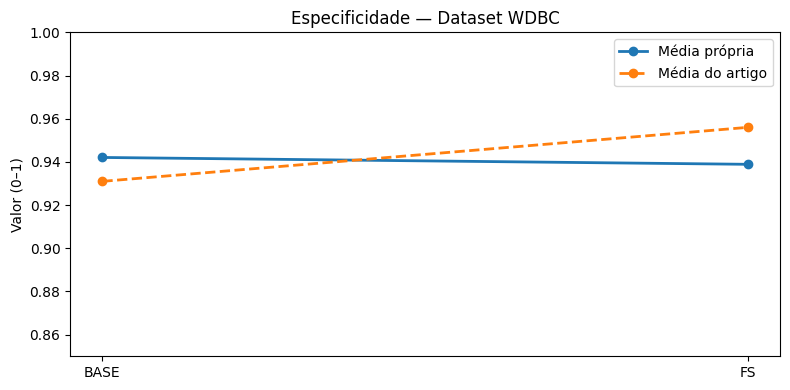

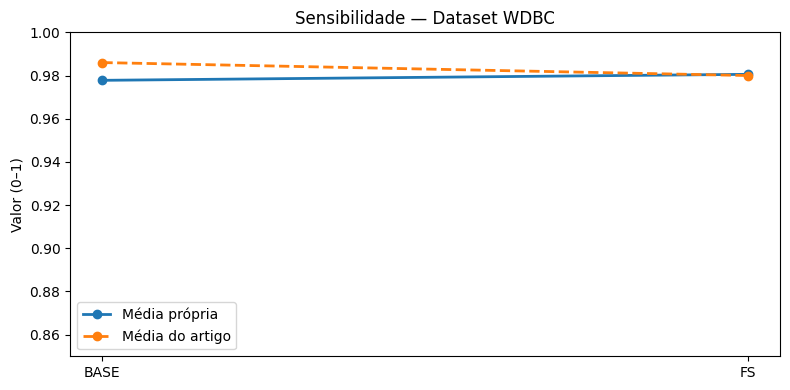

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== ajuste aqui =====
OUTDIR = r".\resultados"
SWAP_SENS_SPEC = True  # True se quiser inverter sens<->spec (convenção de classe positiva)
# =======================

# Valores do artigo (WDBC, Tabela 5) para PSO/PS-classifier
ART_BASE = {"accuracy": 0.964, "sensitivity": 0.986, "specificity": 0.931}
ART_FS   = {"accuracy": 0.972, "sensitivity": 0.980, "specificity": 0.956}

def norm(v):
    return v/100.0 if v > 1 else v

ART_BASE = {k: norm(v) for k, v in ART_BASE.items()}
ART_FS   = {k: norm(v) for k, v in ART_FS.items()}

if SWAP_SENS_SPEC:
    ART_BASE["sensitivity"], ART_BASE["specificity"] = ART_BASE["specificity"], ART_BASE["sensitivity"]
    ART_FS["sensitivity"], ART_FS["specificity"]     = ART_FS["specificity"], ART_FS["sensitivity"]

df = pd.read_csv(f"{OUTDIR}\\wdbc_results_per_repeat.csv")

# médias dos seus resultados
MY_BASE = {
    "accuracy": df["base_accuracy"].mean(),
    "sensitivity": df["base_sensitivity"].mean(),
    "specificity": df["base_specificity"].mean(),
}
MY_FS = {
    "accuracy": df["fs_accuracy"].mean(),
    "sensitivity": df["fs_sensitivity"].mean(),
    "specificity": df["fs_specificity"].mean(),
}

plots = [
    ("accuracy", "Acurácia"),
    ("sensitivity", "Especificidade"),
    ("specificity", "Sensibilidade"),
]

for metric, title in plots:
    plt.figure(figsize=(8, 4))

    xs = ["BASE", "FS"]
    my_vals = [MY_BASE[metric], MY_FS[metric]]
    art_vals = [ART_BASE[metric], ART_FS[metric]]

    plt.plot(xs, my_vals, marker="o", linewidth=2, label="Média própria")
    plt.plot(xs, art_vals, marker="o", linestyle="--", linewidth=2, label="Média do artigo")

    plt.ylim(0.85, 1.0)
    plt.title(f"{title} — Dataset WDBC")
    plt.ylabel("Valor (0–1)")
    plt.legend()
    plt.tight_layout()
    plt.show()
